# Manual Pipeline
- I made a mistake earlier. Should not have skipepd straight to building a pipeline.
- Verify the prior selection on a set of three stars first.
- Here we will do the first one.

---
- In this notebook:
    - Plot the stellar S-Ind data.
    - Run LSP on it.
    - Remove dominant mode.
    - Run LSP on residuals.
    - Flag aliases and window functions.
        - Aliases are harmonics of the dominant signal. For stars the dominant signal is probably $P_rot$
        - Window functions are regular due to observations ie daily, weekly, monthly etc.
    - Ignore these as bias.
    - Remaining peaks above FAP threshold are significant too.
    - Classify those significant peaks. (you alr have this from priors1)
    - Formulate priors.
    - GPR
    -Window analysis.
---
- Here will just do HD81809. 


In [167]:
import pandas as pd
from astropy.time import Time
import matplotlib.pyplot as plt
import celerite2
import numpy as np
from celerite2 import terms
from scipy.optimize import minimize
from prettytable import PrettyTable


# Importing data
data = pd.read_csv(r"./Data/benchmark/HD81809_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)

# data = pd.read_csv(r"./Data/hd166_caii.txt", sep='\s',skip_blank_lines=True)
data.columns = ["JD", "sind"]
data['JD'] = data['JD'] + 2400000.0 # this file drops the 24 prefix
time_obj = Time(data["JD"].to_numpy(), format='jd', scale='tdb')
data["year"] = time_obj.jyear
data["day"] = time_obj.jd 
data['datetime'] = time_obj.to_datetime(timezone=None)
data = data.set_index('datetime')

# No need to down sample the dataset here. yay!
def split_df(df, train_split=0.8, valid_split=0.19):
    n = len(df)
    train_idx = round(train_split * n)
    valid_idx = round((train_split + valid_split) * n)
    return df.iloc[:train_idx].copy(), df.iloc[train_idx:valid_idx].copy(), df.iloc[valid_idx:].copy()

# Split the data
train_df, valid_df, test_df = split_df(data)


C:\Users\Joey\AppData\Local\Temp\ipykernel_6812\3791637440.py:12: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data = pd.read_csv(r"./Data/benchmark/HD81809_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)


- Nu skriver vi en MPFIT:
    - Find dominant peak:
        - Compare with SNR and FAP
        - Significant if peak_power > FAP threshold (and/or SNR > 4)
        - else stop
    - Add best_freq to accepted frequency list
    - Simultaneous re-fit of ALL accepted frequencies
    - Calculate new residuals
    - Repeat with new residuals.

[np.float64(1.0), np.float64(0.0003342623911796942), np.float64(3.3426239117969425e-05), np.float64(0.9984157441111845)]


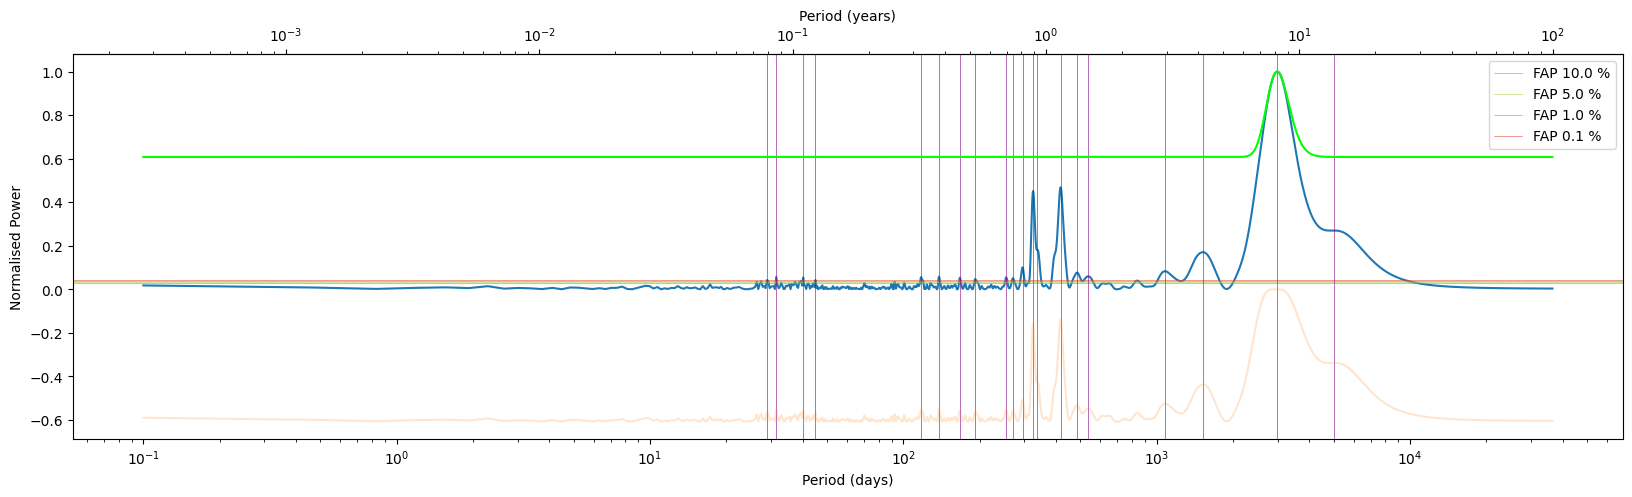

In [ ]:
from astropy.timeseries import LombScargle
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

# Define freq range
min_period = 0.1
max_period = 365*100 # now in days
n_periods = 100000
periods = np.linspace(min_period, max_period, n_periods)
freqs = 1 / periods

## Round 1
resid = train_df['sind']
t = train_df['day']

# Take the LSP
ls = LombScargle(t, resid)
powers = ls.power(freqs) # Pulls out the powers at those frequencies

# Normalisation for interpretability
max_power = max(powers)
powers /= max_power

# Calculate FAPs
FAPs = np.array([10,5,1,0.1])/100
power_invFAPs = ls.false_alarm_level(FAPs, method = 'bootstrap') 
power_invFAPs /= max_power # Normalise onto our scale of 0 to 1

# Identify peaks above 0.1 FAP
peak_idxs, properties = find_peaks(powers, height = float(power_invFAPs[-1])) # peaks is an array of the indices of the input arrays with the peaks
peak_periods = periods[peak_idxs]

## Plot
fig, ax = plt.subplots(figsize=(20, 5))
ax.set_xscale('log')
# ax.set_yscale('log')
ax.plot(periods, powers)

# Axis labels
ax2 = ax.secondary_xaxis('top', functions=(lambda d: d / 365.25, lambda y: y * 365.25))
ax2.set_xlabel('Period (years)')
ax.set_xlabel('Period (days)')
ax.set_ylabel('Normalised Power')

# Plot FAPs
fap_colors = ['#2ecc71', '#a8d44a', '#e67e22', '#e74c3c']
for power_invFAP, fap_color, fap_level in zip(power_invFAPs, fap_colors, FAPs):
    ax.axhline(power_invFAP, color = fap_color, label = f'FAP {fap_level * 100} %', lw = 0.4)

# Plot peaks
for peak_period in peak_periods:
    ax.axvline(peak_period, color = 'purple', lw = 0.4)


# Take the dominant period
peak_heights = properties['peak_heights']
dom_idx = np.argmax(peak_heights) # Index of dominant period in peaks list
dom_peak_idx = peak_idxs[dom_idx] # Concomitant idx in the powers 
dominant_period = peak_periods[dom_idx]

# Perform SNR check
def gaussian(t, A, mu, std, c):
    return A * np.exp(-0.5 * ((t - mu) / std)**2) + c

def find_snr(powers, freqs, dom_idx, dom_peak_idx, peak_periods, peak_heights, window = 150):
    n = len(powers)
    left  = max(0, dom_peak_idx - window)
    right = min(n, dom_peak_idx + window + 1)

    lim_powers = powers[left:right]
    lim_freqs = freqs[left:right]

    minf = min(lim_freqs)
    maxf = max(lim_freqs)

    A0 = peak_heights[dom_idx]
    mu0 = 1/peak_periods[dom_idx]
    # Use 10% of the centre frequency so std0 stays sensible even when the
    # window extends to the high-frequency edge (freqs[0]=10).
    std0 = mu0 * 0.1
    c0 = np.median(lim_powers)
    p0 = [A0, mu0, std0, c0]
    print(p0)

    try:
        popt, pcov = curve_fit(gaussian, lim_freqs, lim_powers,
                                            p0 = p0,
                                            bounds = ([0, minf, 0, 0], [np.inf, maxf, np.inf, np.inf]),
                                            )
        # LSP residual defined noise floor
        resid_lsp = lim_powers - gaussian(lim_freqs, *popt)
        noise_std = np.std(resid_lsp) # Noise fluctuation
        snr = A0 / noise_std
        return snr, popt, resid_lsp
    except (RuntimeError, ValueError):
        # RuntimeError: fit did not converge; ValueError: bounds/guess issue
        noise = np.mean(lim_powers)
        return powers[dom_idx] / noise, None, None

snr, popt, resid_lsp = find_snr(powers, freqs, dom_idx, dom_peak_idx, peak_periods, peak_heights)

if popt is not None:
    ax.plot(periods, gaussian(freqs, *popt), color = 'lime')
    ax.plot(periods, powers-gaussian(freqs, *popt), alpha = 0.2)

accepted_periods = []

if snr >4:
    accepted_periods.append(dominant_period)

plt.legend()
plt.show()

# Now do the simultneous fit based on all the accepted periods
def build_design_matrix(t, accepted_periods):
    cols = [np.ones(len(t))]
    for p in accepted_periods:
        cols.append(np.cos(2 * np.pi * t / p))
        cols.append(np.sin(2 * np.pi * t / p))
    return np.column_stack(cols)

def simultaneous_fit(t, y, accepted_freqs):
    X = build_design_matrix(t, accepted_freqs)
    params, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    fitted = X @ params
    residuals = y - fitted
    return residuals, params

resid1, params = simultaneous_fit(train_df['day'], train_df['sind'], accepted_periods)


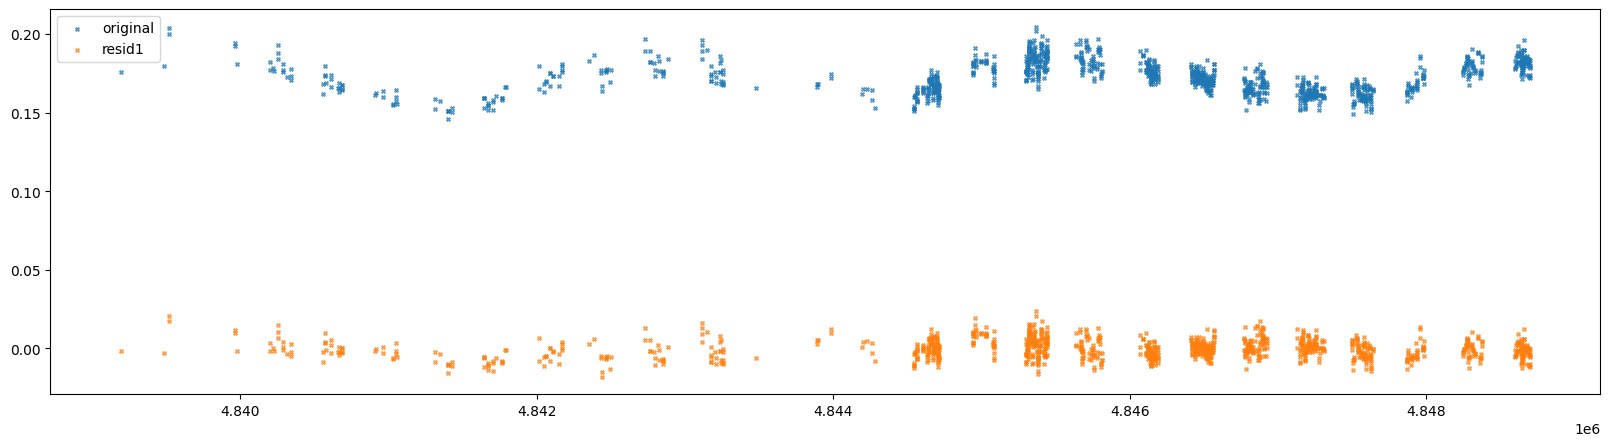

In [169]:
fig = plt.figure(figsize=(20,5))
plt.scatter(train_df['day'], train_df['sind'], marker='x', s=7, alpha=0.75, label = 'original')
plt.scatter(train_df['day'], resid1, marker='x', s=7, alpha=0.75, label = "resid1")
plt.legend()
plt.show()

Accepted: [np.float64(2991.6617196171965)]
Windows: [365.25, 182.625, 121.75, 91.3125, 30.4375, 60.875, 7, 14, 21]
Aliases: [747.9154299042991, 987.2483674736749, 1495.8308598085982, 5983.323439234393, 8974.985158851588, 11966.646878468786]
+--------------------+--------------------+
|       Period       |       Height       |
+--------------------+--------------------+
| 40.25029150291503  |        1.0         |
| 7124.951728517286  | 0.9786098572484523 |
| 44.26532065320654  | 0.8940262049557439 |
| 1550.9962599625997 | 0.8817522841899694 |
| 2082.440118401184  | 0.829870726820948  |
| 41.710302103021036 | 0.7842563747914428 |
| 343.2024910249103  | 0.7432194357089779 |
| 35.50525705257053  | 0.7141680683900115 |
| 384.08278782787835 | 0.6663663778924205 |
| 315.82729227292276 | 0.6094548902676354 |
| 17.255124551245515 | 0.5856450362081932 |
| 96.82570225702257  | 0.5696684214931818 |
| 42.44030740307404  | 0.5589911708828851 |
| 39.52028620286203  | 0.5542894720184465 |
| 37.330270

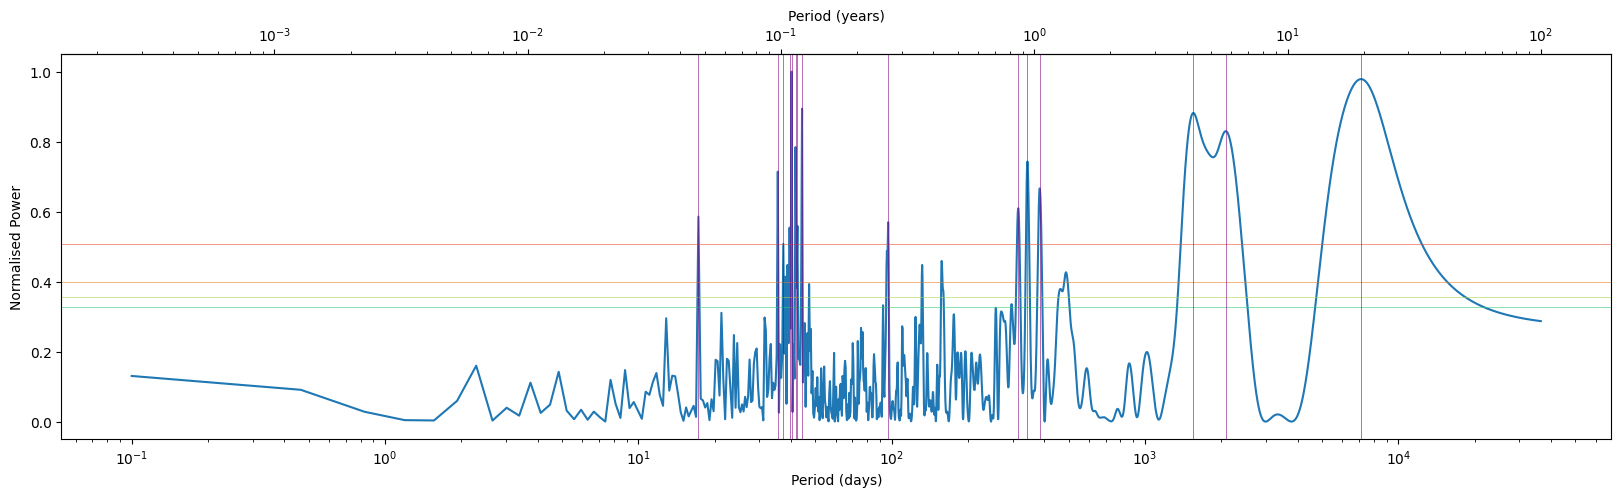

In [170]:
## ROUND 2

# Take the LSP
ls = LombScargle(t, resid1)
powers = ls.power(freqs) # Pulls out the powers at those frequencies

# Normalisation for interpretability
max_power = max(powers)
powers /= max_power

# Calculate FAPs
FAPs = np.array([10,5,1,0.1])/100
power_invFAPs = ls.false_alarm_level(FAPs, method = 'bootstrap') 
power_invFAPs /= max_power # Normalise onto our scale of 0 to 1

# Identify peaks above 0.1 FAP
peak_idxs, properties = find_peaks(powers, height = float(power_invFAPs[-1])) # peaks is an array of the indices of the input arrays with the peaks
peak_periods = periods[peak_idxs]

## Plot
fig, ax = plt.subplots(figsize=(20, 5))
ax.set_xscale('log')
# ax.set_yscale('log')
ax.plot(periods, powers)

# Axis labels
ax2 = ax.secondary_xaxis('top', functions=(lambda d: d / 365.25, lambda y: y * 365.25))
ax2.set_xlabel('Period (years)')
ax.set_xlabel('Period (days)')
ax.set_ylabel('Normalised Power')

# Plot FAPs
fap_colors = ['#2ecc71', '#a8d44a', '#e67e22', '#e74c3c']
for power_invFAP, fap_color, fap_level in zip(power_invFAPs, fap_colors, FAPs):
    ax.axhline(power_invFAP, color = fap_color, label = f'FAP {fap_level * 100} %', lw = 0.4)

# Plot peaks
for peak_period in peak_periods:
    ax.axvline(peak_period, color = 'purple', lw = 0.4)


# CHECK FOR ALIASES AND WINDOWS

# Loop through the peaks and find the first one that isn't an alias or window and perform the removal analysis
# peak_idxs, properties['peak_heights'], 

peak_heights = properties['peak_heights']

# Sort by peak heights — must sort peak_idxs alongside so dom_peak_idx stays correct
sorted_idxs = np.argsort(peak_heights)[::-1]
peak_idxs = peak_idxs[sorted_idxs]
peak_periods = peak_periods[sorted_idxs]
peak_heights = peak_heights[sorted_idxs]

# Take the dominant period
dom_idx = np.argmax(peak_heights) # Index of dominant period in peaks list (= 0 after sort)
dom_peak_idx = peak_idxs[dom_idx] # Concomitant idx in the powers 
dominant_period = peak_periods[dom_idx]

table = PrettyTable(["Period", "Height"])
for peak_period, peak_height in zip(peak_periods, peak_heights):
     table.add_row([peak_period, peak_height])

year = 365.25
month = year /12
week = 7
windows = [year, year/2, year/3, year/4, month, 2*month, week, 2* week, 3 * week]
print(f"Accepted: {accepted_periods}")
print(f"Windows: {windows}")
aliases = []
for p in accepted_periods:
    for mult in [0.25, 0.33, 0.5, 2, 3, 4]:
        aliases.append(float(mult * p))
print(f"Aliases: {aliases}")
print(table)


In [171]:
def check_aliases(period, accepted_periods, tol = 0.05):
    '''
    Check if a single period is an alias.
    If it is an alias we can skip it and use the next period as dominant.
    Aliases are not subtracted: they are noise.
    If False, signal is not an alias so set it be added.
    '''
    for p in accepted_periods:
        for mult in [0.25, 0.33, 0.5, 2, 3, 4]:
            delta = np.abs((period - p*mult)/period)
            if delta < tol: # The signal is an alias
                return True, p*mult, delta
    return False, None, None

def check_windows(period, tol = 0.05):
    '''
    Checks if a signal looks suspiciously like a window function.
    If False, signal is not a window as defined.
    '''
    year = 365.25
    month = year /12
    week = 7
    windows = [year, year/2, year/3, year/4, month, 2*month, week, 2* week, 3 * week]
    for window in windows:
        delta = np.abs((period-window)/period)
        if delta < tol: # Then we classify the signal as a window function
            return True
    return False 

# None of them should be aliases or window functions by manual inspection. Now, compare.
print(check_aliases(peak_periods[0], accepted_periods))
print(check_windows(peak_periods[0]))

(False, None, None)
False


- OK so the dominant here is not a window or alias.
- Now, fit gaussian and check SNR.
- If SNR > 4 append to accepted periods list.

[np.float64(1.0), np.float64(0.02484454056506839), np.float64(0.0024844540565068392), np.float64(0.07644603480956784)]
8.756439606779143


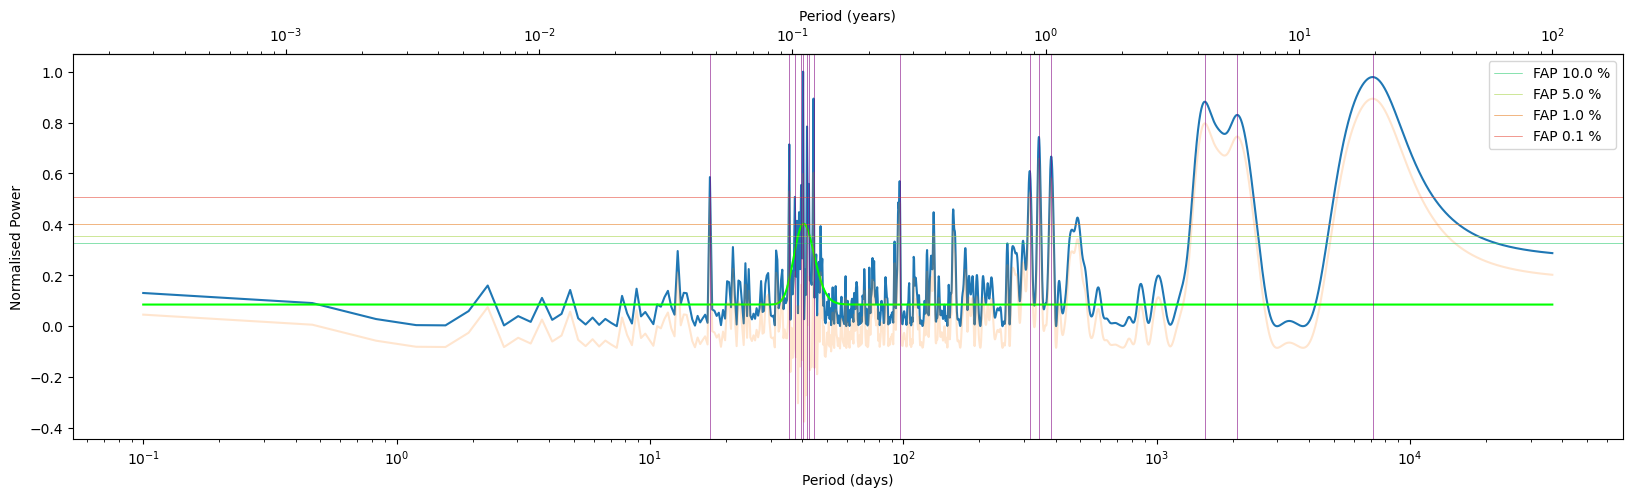

In [172]:
snr, popt, resid_lsp = find_snr(powers, freqs, dom_idx, dom_peak_idx, peak_periods, peak_heights)

print(snr)

# Accumulate — do NOT reset accepted_periods here (MPFIT keeps all accepted periods)
if snr > 4:
    accepted_periods.append(dominant_period)

## Plot
fig, ax = plt.subplots(figsize=(20, 5))
ax.set_xscale('log')
# ax.set_yscale('log')
ax.plot(periods, powers)

if popt is not None:
    ax.plot(periods, gaussian(freqs, *popt), color = 'lime')
    ax.plot(periods, powers-gaussian(freqs, *popt), alpha = 0.2)

# Axis labels
ax2 = ax.secondary_xaxis('top', functions=(lambda d: d / 365.25, lambda y: y * 365.25))
ax2.set_xlabel('Period (years)')
ax.set_xlabel('Period (days)')
ax.set_ylabel('Normalised Power')

# Plot FAPs
fap_colors = ['#2ecc71', '#a8d44a', '#e67e22', '#e74c3c']
for power_invFAP, fap_color, fap_level in zip(power_invFAPs, fap_colors, FAPs):
    ax.axhline(power_invFAP, color = fap_color, label = f'FAP {fap_level * 100} %', lw = 0.4)

# Plot peaks
for peak_period in peak_periods:
    ax.axvline(peak_period, color = 'purple', lw = 0.4)

plt.legend()
plt.show()


- Ok so the SNR is greater than four.
- Now we perform the simultaneous refit.

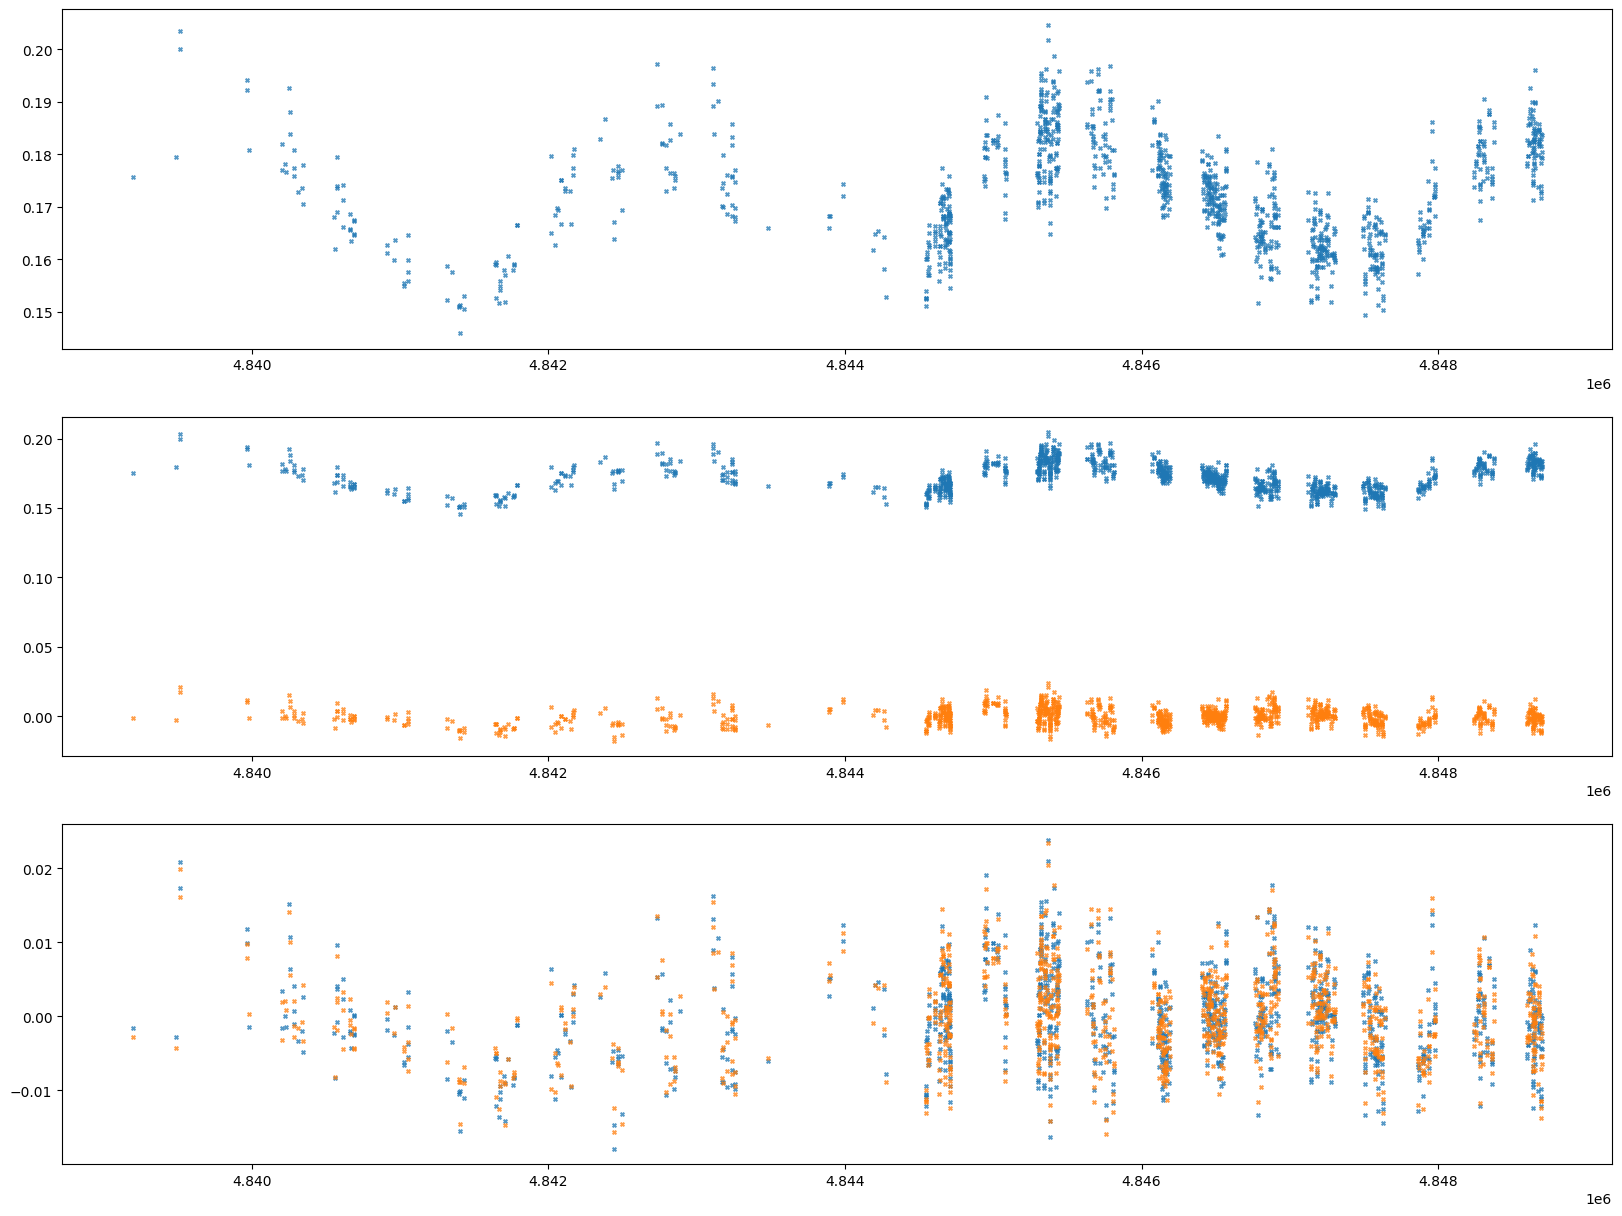

In [173]:
resid2, params = simultaneous_fit(train_df['day'], train_df['sind'], accepted_periods)
fig, ax = plt.subplots(3, figsize=(20,3*5))
ax[0].scatter(train_df['day'], train_df['sind'], marker='x', s=7, alpha=0.75, label = 'original')
ax[1].scatter(train_df['day'], train_df['sind'], marker='x', s=7, alpha=0.75, label = 'original')
ax[1].scatter(train_df['day'], resid1, marker='x', s=7, alpha=0.75, label = "resid1")
ax[2].scatter(train_df['day'], resid1, marker='x', s=7, alpha=0.75, label = "resid1")
ax[2].scatter(train_df['day'], resid2, marker='x', s=7, alpha=0.75, label = "resid2")

plt.show()

- Now we repeat!

Peak periods: [  44.26532065 1583.11649316 1999.2195142  7103.05156952  343.20249102
   42.4403074    35.50525705   41.7103021   315.46228962   39.5202862
  384.08278783   37.3302703 ]
Accepted: [np.float64(2991.6617196171965), np.float64(40.25029150291503)]
Windows: [365.25, 182.625, 121.75, 91.3125, 30.4375, 60.875, 7, 14, 21]
Aliases: [747.9154299042991, 987.2483674736749, 1495.8308598085982, 5983.323439234393, 8974.985158851588, 11966.646878468786, 10.062572875728758, 13.282596195961961, 20.125145751457516, 80.50058300583007, 120.7508745087451, 161.00116601166013]
+--------------------+--------------------+
|       Period       |       Height       |
+--------------------+--------------------+
| 44.26532065320654  |        1.0         |
| 1583.1164931649316 | 0.8560474270570608 |
| 1999.219514195142  | 0.818937568954489  |
| 7103.0515695156955 | 0.8083308058749734 |
| 343.2024910249103  | 0.699475277020863  |
| 42.44030740307404  | 0.6675466018084447 |
| 35.50525705257053  | 0.6670

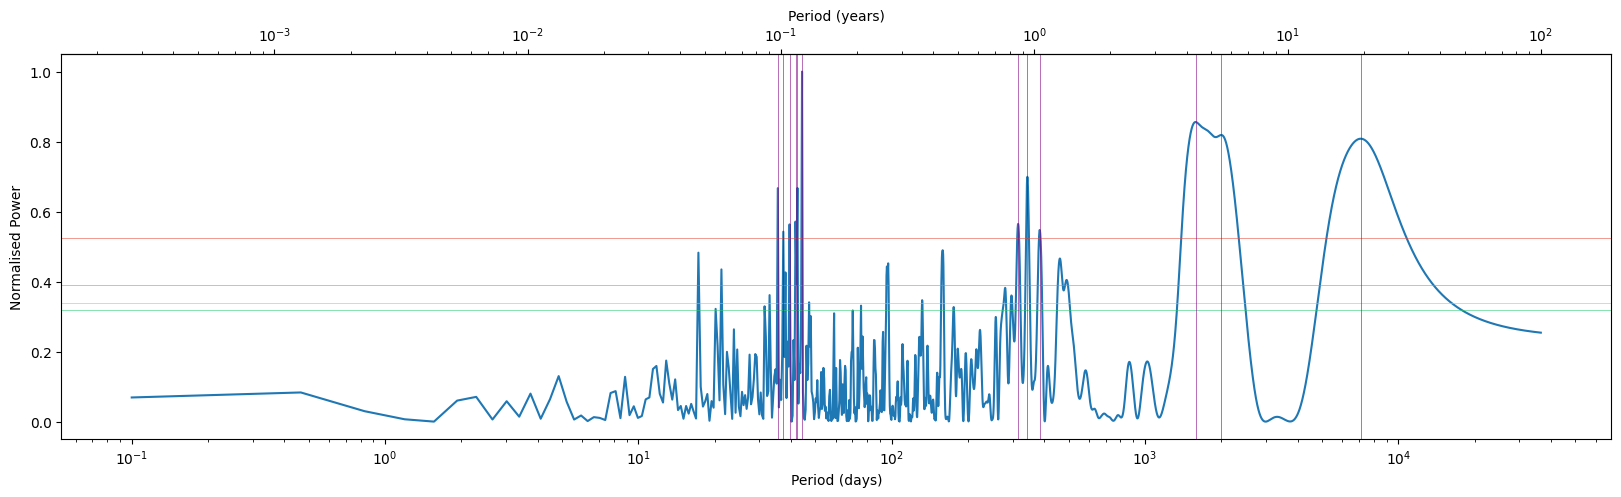

In [174]:
## ROUND 2

# Take the LSP
ls = LombScargle(t, resid2)
powers = ls.power(freqs) # Pulls out the powers at those frequencies

# Normalisation for interpretability
max_power = max(powers)
powers /= max_power

# Calculate FAPs
FAPs = np.array([10,5,1,0.1])/100
power_invFAPs = ls.false_alarm_level(FAPs, method = 'bootstrap') 
power_invFAPs /= max_power # Normalise onto our scale of 0 to 1

# Identify peaks above 0.1 FAP
peak_idxs, properties = find_peaks(powers, height = float(power_invFAPs[-1])) # peaks is an array of the indices of the input arrays with the peaks
peak_periods = periods[peak_idxs]

## Plot
fig, ax = plt.subplots(figsize=(20, 5))
ax.set_xscale('log')
# ax.set_yscale('log')
ax.plot(periods, powers)

# Axis labels
ax2 = ax.secondary_xaxis('top', functions=(lambda d: d / 365.25, lambda y: y * 365.25))
ax2.set_xlabel('Period (years)')
ax.set_xlabel('Period (days)')
ax.set_ylabel('Normalised Power')

# Plot FAPs
fap_colors = ['#2ecc71', '#a8d44a', '#e67e22', '#e74c3c']
for power_invFAP, fap_color, fap_level in zip(power_invFAPs, fap_colors, FAPs):
    ax.axhline(power_invFAP, color = fap_color, label = f'FAP {fap_level * 100} %', lw = 0.4)

# Plot peaks
for peak_period in peak_periods:
    ax.axvline(peak_period, color = 'purple', lw = 0.4)


# CHECK FOR ALIASES AND WINDOWS

# Loop through the peaks and find the first one that isn't an alias or window and perform the removal analysis
# peak_idxs, properties['peak_heights'], 

peak_heights = properties['peak_heights']

# Sort by peak heights — must sort peak_idxs alongside so dom_peak_idx stays correct
sorted_idxs = np.argsort(peak_heights)[::-1]
peak_idxs = peak_idxs[sorted_idxs]
peak_periods = peak_periods[sorted_idxs]
print(f"Peak periods: {peak_periods}")
peak_heights = peak_heights[sorted_idxs]

# Take the dominant period
dom_idx = np.argmax(peak_heights) # Index of dominant period in peaks list (= 0 after sort)
dom_peak_idx = peak_idxs[dom_idx] # Concomitant idx in the powers 
dominant_period = peak_periods[dom_idx]

table = PrettyTable(["Period", "Height"])
for peak_period, peak_height in zip(peak_periods, peak_heights):
     table.add_row([peak_period, peak_height])

year = 365.25
month = year /12
week = 7
windows = [year, year/2, year/3, year/4, month, 2*month, week, 2* week, 3 * week]
print(f"Accepted: {accepted_periods}")
print(f"Windows: {windows}")
aliases = []
for p in accepted_periods:
    for mult in [0.25, 0.33, 0.5, 2, 3, 4]:
        aliases.append(float(mult * p))
print(f"Aliases: {aliases}")
print(table)


- Does not look like an alias or window by inspection of the numbers.

In [175]:
# None of them should be aliases or window functions by manual inspection. Now, compare.
print(check_aliases(peak_periods[0], accepted_periods))
print(check_windows(peak_periods[0]))

(False, None, None)
False


- Now we do the SNR analysis.

[np.float64(1.0), np.float64(0.022591048370222546), np.float64(0.0022591048370222545), np.float64(0.06738283267322898)]
8.003466841255673


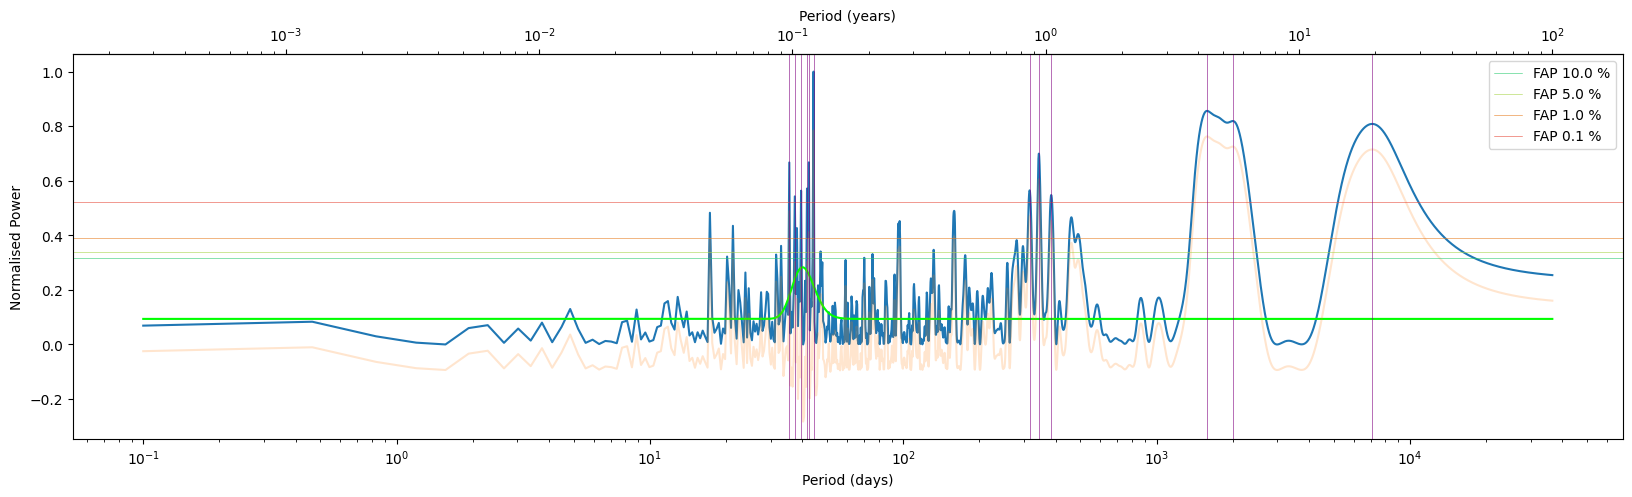

In [176]:
snr, popt, resid_lsp = find_snr(powers, freqs, dom_idx, dom_peak_idx, peak_periods, peak_heights)

print(snr)

# Accumulate — do NOT reset accepted_periods here (MPFIT keeps all accepted periods)
if snr > 4:
    accepted_periods.append(dominant_period)

## Plot
fig, ax = plt.subplots(figsize=(20, 5))
ax.set_xscale('log')
# ax.set_yscale('log')
ax.plot(periods, powers)

if popt is not None:
    ax.plot(periods, gaussian(freqs, *popt), color = 'lime')
    ax.plot(periods, powers-gaussian(freqs, *popt), alpha = 0.2)

# Axis labels
ax2 = ax.secondary_xaxis('top', functions=(lambda d: d / 365.25, lambda y: y * 365.25))
ax2.set_xlabel('Period (years)')
ax.set_xlabel('Period (days)')
ax.set_ylabel('Normalised Power')

# Plot FAPs
fap_colors = ['#2ecc71', '#a8d44a', '#e67e22', '#e74c3c']
for power_invFAP, fap_color, fap_level in zip(power_invFAPs, fap_colors, FAPs):
    ax.axhline(power_invFAP, color = fap_color, label = f'FAP {fap_level * 100} %', lw = 0.4)

# Plot peaks
for peak_period in peak_periods:
    ax.axvline(peak_period, color = 'purple', lw = 0.4)

plt.legend()
plt.show()


- This passes the SNR test so add period and perform the refitting.


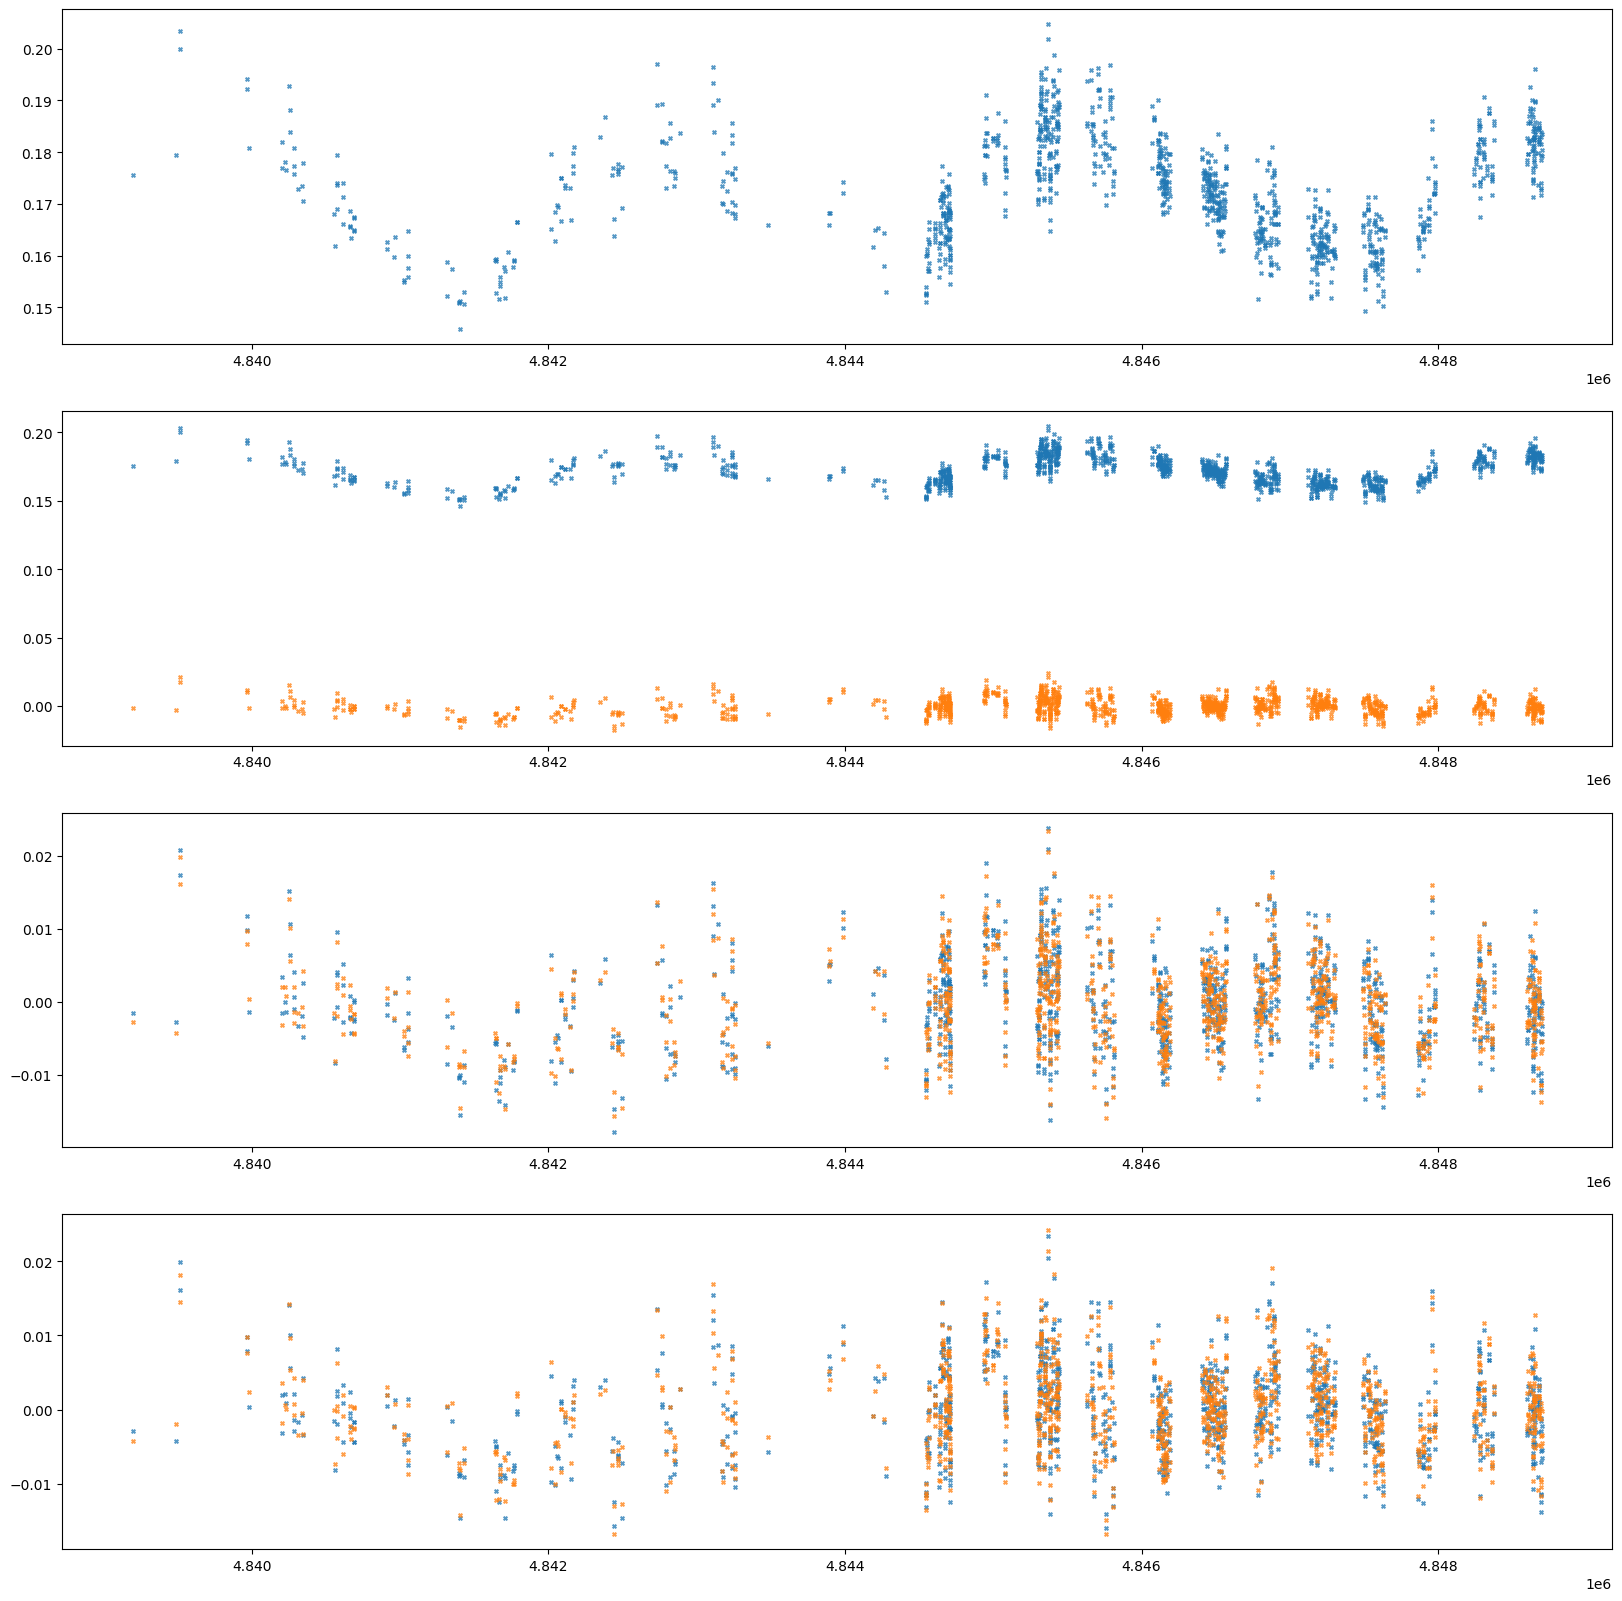

In [177]:
resid3, params = simultaneous_fit(train_df['day'], train_df['sind'], accepted_periods)
fig, ax = plt.subplots(4, figsize=(20,4*5))
ax[0].scatter(train_df['day'], train_df['sind'], marker='x', s=7, alpha=0.75, label = 'original')
ax[1].scatter(train_df['day'], train_df['sind'], marker='x', s=7, alpha=0.75, label = 'original')
ax[1].scatter(train_df['day'], resid1, marker='x', s=7, alpha=0.75, label = "resid1")
ax[2].scatter(train_df['day'], resid1, marker='x', s=7, alpha=0.75, label = "resid1")
ax[2].scatter(train_df['day'], resid2, marker='x', s=7, alpha=0.75, label = "resid2")
ax[3].scatter(train_df['day'], resid2, marker='x', s=7, alpha=0.75, label = "resid2")
ax[3].scatter(train_df['day'], resid3, marker='x', s=7, alpha=0.75, label = "resid3")

plt.show()

- Now repeat

Peak periods: [1813.06816268   41.7103021  7324.24317543  315.09728697   42.4403074
  342.83748837   37.3302703    21.2701537    35.50525705   17.25512455
   95.73069431  158.51115011]
Accepted: [np.float64(2991.6617196171965), np.float64(40.25029150291503), np.float64(44.26532065320654)]
Windows: [365.25, 182.625, 121.75, 91.3125, 30.4375, 60.875, 7, 14, 21]
Aliases: [747.9154299042991, 987.2483674736749, 1495.8308598085982, 5983.323439234393, 8974.985158851588, 11966.646878468786, 10.062572875728758, 13.282596195961961, 20.125145751457516, 80.50058300583007, 120.7508745087451, 161.00116601166013, 11.066330163301634, 14.607555815558158, 22.13266032660327, 88.53064130641307, 132.7959619596196, 177.06128261282615]
+--------------------+--------------------+
|       Period       |       Height       |
+--------------------+--------------------+
| 1813.0681626816267 |        1.0         |
| 41.710302103021036 | 0.7339708430452799 |
| 7324.243175431755  | 0.6717519744370236 |
| 315.0972869

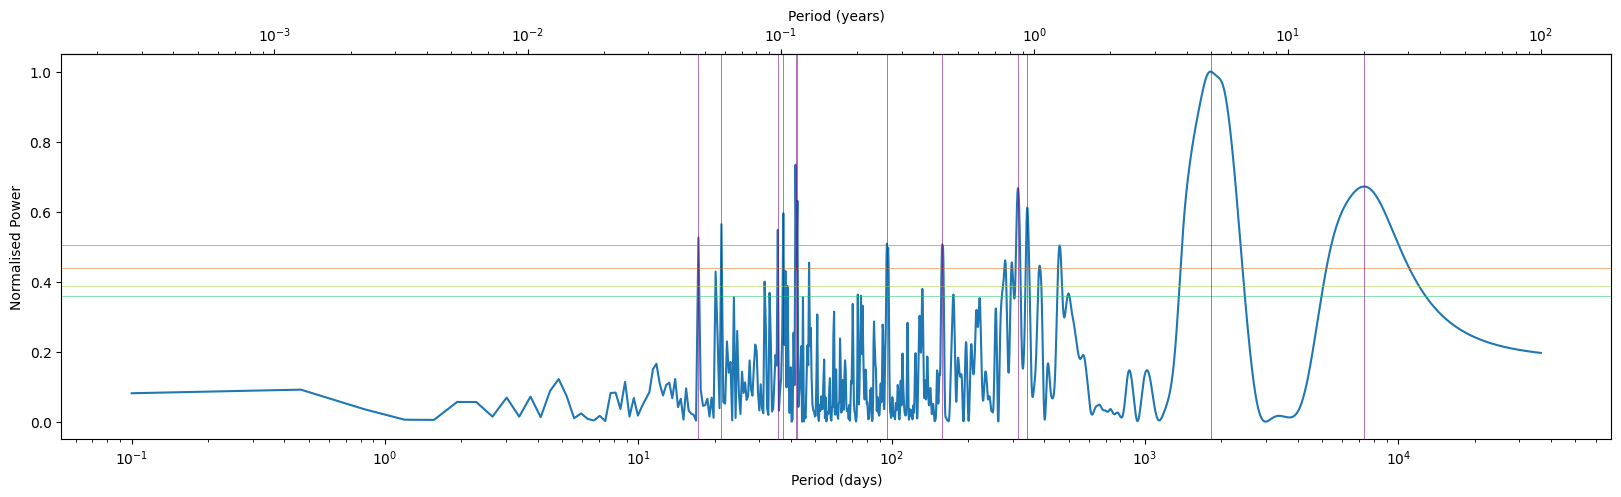

In [178]:
## ROUND 3

# Take the LSP
ls = LombScargle(t, resid3)
powers = ls.power(freqs) # Pulls out the powers at those frequencies

# Normalisation for interpretability
max_power = max(powers)
powers /= max_power

# Calculate FAPs
FAPs = np.array([10,5,1,0.1])/100
power_invFAPs = ls.false_alarm_level(FAPs, method = 'bootstrap') 
power_invFAPs /= max_power # Normalise onto our scale of 0 to 1

# Identify peaks above 0.1 FAP
peak_idxs, properties = find_peaks(powers, height = float(power_invFAPs[-1])) # peaks is an array of the indices of the input arrays with the peaks
peak_periods = periods[peak_idxs]

## Plot
fig, ax = plt.subplots(figsize=(20, 5))
ax.set_xscale('log')
# ax.set_yscale('log')
ax.plot(periods, powers)

# Axis labels
ax2 = ax.secondary_xaxis('top', functions=(lambda d: d / 365.25, lambda y: y * 365.25))
ax2.set_xlabel('Period (years)')
ax.set_xlabel('Period (days)')
ax.set_ylabel('Normalised Power')

# Plot FAPs
fap_colors = ['#2ecc71', '#a8d44a', '#e67e22', '#e74c3c']
for power_invFAP, fap_color, fap_level in zip(power_invFAPs, fap_colors, FAPs):
    ax.axhline(power_invFAP, color = fap_color, label = f'FAP {fap_level * 100} %', lw = 0.4)

# Plot peaks
for peak_period in peak_periods:
    ax.axvline(peak_period, color = 'purple', lw = 0.4)


# CHECK FOR ALIASES AND WINDOWS

# Loop through the peaks and find the first one that isn't an alias or window and perform the removal analysis
# peak_idxs, properties['peak_heights'], 

peak_heights = properties['peak_heights']

# Sort by peak heights — must sort peak_idxs alongside so dom_peak_idx stays correct
sorted_idxs = np.argsort(peak_heights)[::-1]
peak_idxs = peak_idxs[sorted_idxs]
peak_periods = peak_periods[sorted_idxs]
print(f"Peak periods: {peak_periods}")
peak_heights = peak_heights[sorted_idxs]

if len(peak_heights) != 0:
    # Take the dominant period
    dom_idx = np.argmax(peak_heights) # Index of dominant period in peaks list (= 0 after sort)
    dom_peak_idx = peak_idxs[dom_idx] # Concomitant idx in the powers 
    dominant_period = peak_periods[dom_idx]

    table = PrettyTable(["Period", "Height"])
    for peak_period, peak_height in zip(peak_periods, peak_heights):
        table.add_row([peak_period, peak_height])

    year = 365.25
    month = year /12
    week = 7
    windows = [year, year/2, year/3, year/4, month, 2*month, week, 2* week, 3 * week]
    print(f"Accepted: {accepted_periods}")
    print(f"Windows: {windows}")
    aliases = []
    for p in accepted_periods:
        for mult in [0.25, 0.33, 0.5, 2, 3, 4]:
            aliases.append(float(mult * p))
    print(f"Aliases: {aliases}")
    print(table)
else:
    print("No significant peaks")


- Now we have our final list of accepted periods.

In [179]:
table = PrettyTable(["Days", "Years"])
for accepted_period in accepted_periods:
    table.add_row([f"{accepted_period:.2f}", f"{accepted_period/365:.2f}"])
print("Periods")
print(table)

Periods
+---------+-------+
|   Days  | Years |
+---------+-------+
| 2991.66 |  8.20 |
|  40.25  |  0.11 |
|  44.27  |  0.12 |
+---------+-------+


- HD81809

From literature:
  - Rotation period: 39.3 days
  - Cycle period: ~8.2 years (~2995 days)
  - Reference: the linked paper (real.mtak.hu)

- All in all this works ok.
- Very senstive the n_points. Try autopower.
- How to prevent very similar periods from showing up ie 40 and 44 days. These are the same signal, no?